In [1]:
!pip install -q osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.3 MB/s eta 0:00:00


In [3]:
import osmnx as ox

In [14]:
place = "Chico, California, USA"
G = ox.graph_from_place(place, network_type="walk")
print (G)

MultiDiGraph with 16936 nodes and 48470 edges


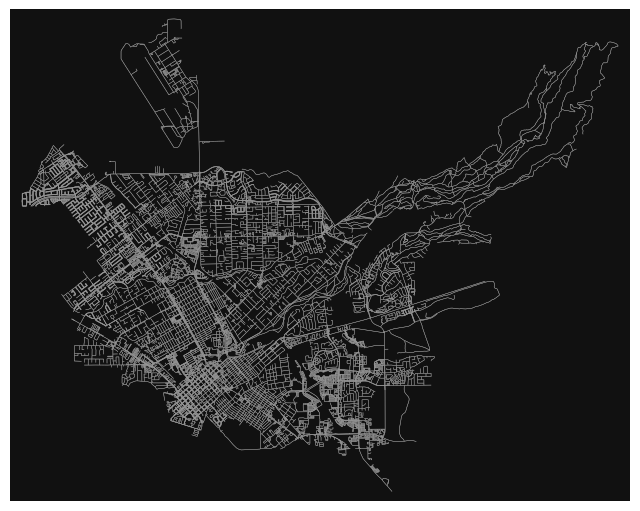

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.3)

In [17]:
print(G.graph["crs"])

epsg:4326


In [18]:
G_proj = ox.project_graph(G)
print(G_proj.graph["crs"])

EPSG:32610


In [19]:
import random

edges = list(G_proj.edges(keys=True, data=True))
sample = random.sample(edges, 5)
for u, v, k, d in sample:
    print(round(d["length"], 1), "m —", d.get("name", "unnamed"))

14.3 m — unnamed
318.3 m — unnamed
124.9 m — Esplanade
48.3 m — Manzanita Avenue
104.1 m — Degarmo Drive


In [20]:
node = list(G_proj.nodes(data=True))[0]
print(node)

(86370357, {'y': 4400793.400362542, 'x': 603156.8414986958, 'street_count': 4})


In [21]:
tags = {"building": True}
gdf = ox.features_from_place(place, tags)
print(len(gdf), "features")
print(gdf.crs)

14920 features
epsg:4326


In [22]:
buildings = ox.projection.project_gdf(gdf)
print(buildings.crs)

EPSG:32610


In [23]:
cols = [c for c in buildings.columns if "height" in c or "level" in c]
print(cols)
print(buildings[cols].notna().sum())

['building:levels', 'building:levels:underground', 'roof:levels', 'level', 'height']
building:levels                939
building:levels:underground      7
roof:levels                      8
level                            6
height                           1
dtype: int64


In [24]:
print("total features:", len(buildings))
print(buildings.geom_type.value_counts())

buildings = buildings[buildings.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
print("polygons only:", len(buildings))

total features: 14920
Polygon    14915
Point          5
Name: count, dtype: int64
polygons only: 14915


In [26]:
import numpy as np
import pandas as pd

METERS_PER_LEVEL = 3.0
DEFAULT_HEIGHT_M = 6.0   # assume a modest 2-storey building

h = np.full(len(buildings), np.nan)
source = np.array(["default"] * len(buildings), dtype=object)

# tier 2: floor counts
levels = pd.to_numeric(buildings.get("building:levels"), errors="coerce")
mask = levels.notna().values
h[mask] = levels[mask].values * METERS_PER_LEVEL
source[mask] = "levels"

# tier 1: explicit height, overrides levels
height = pd.to_numeric(buildings.get("height"), errors="coerce")
mask = height.notna().values
h[mask] = height[mask].values
source[mask] = "tagged"

h[np.isnan(h)] = DEFAULT_HEIGHT_M

buildings["height_m"] = h
buildings["height_source"] = source

print(buildings["height_source"].value_counts())
print(buildings["height_m"].describe())

height_source
default    13975
levels       939
tagged         1
Name: count, dtype: int64
count    14915.000000
mean         5.921757
std          0.617005
min          3.000000
25%          6.000000
50%          6.000000
75%          6.000000
max         27.000000
Name: height_m, dtype: float64


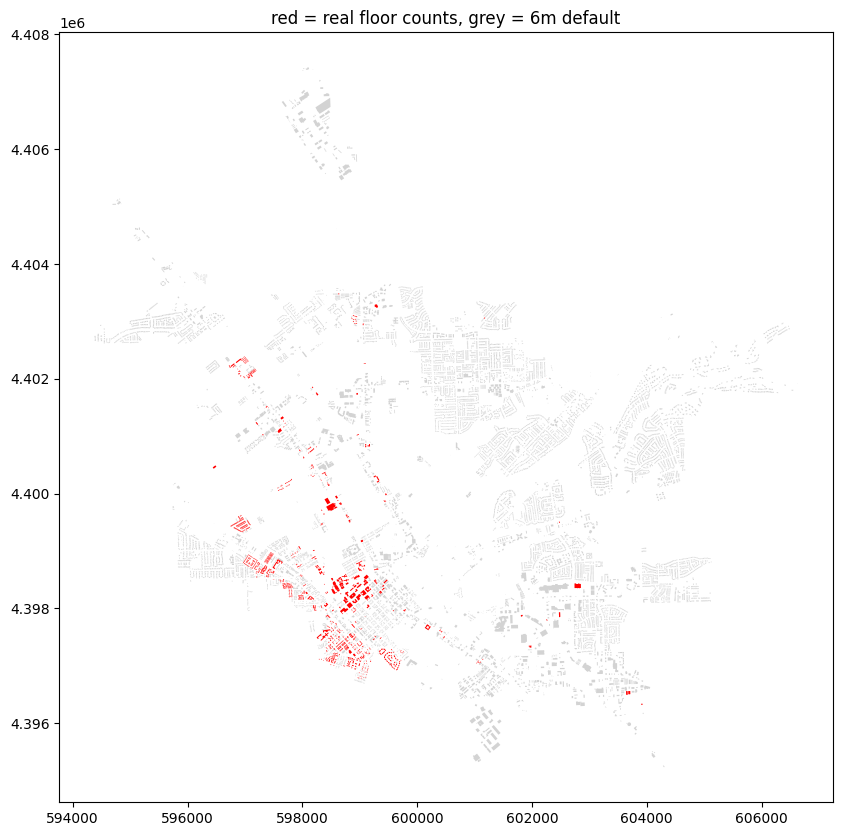

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
buildings[buildings.height_source == "default"].plot(
    ax=ax, color="lightgrey", linewidth=0)
buildings[buildings.height_source == "levels"].plot(
    ax=ax, color="red", linewidth=0)
ax.set_title("red = real floor counts, grey = 6m default")
plt.show()

In [40]:
center_lat, center_lon = 39.7458, -121.8477
radius_m = 800

G_small = ox.graph_from_point(
    (center_lat, center_lon), dist=radius_m, network_type="walk"
)
G_small = ox.project_graph(G_small)
print(G_small)

MultiDiGraph with 987 nodes and 2992 edges


In [41]:
minx, miny, maxx, maxy = (
    ox.graph_to_gdfs(G_small, nodes=False).total_bounds
)
b_small = buildings.cx[minx:maxx, miny:maxy].copy()
print(len(b_small), "buildings")
print(b_small.height_source.value_counts())

277 buildings
height_source
default    228
levels      49
Name: count, dtype: int64


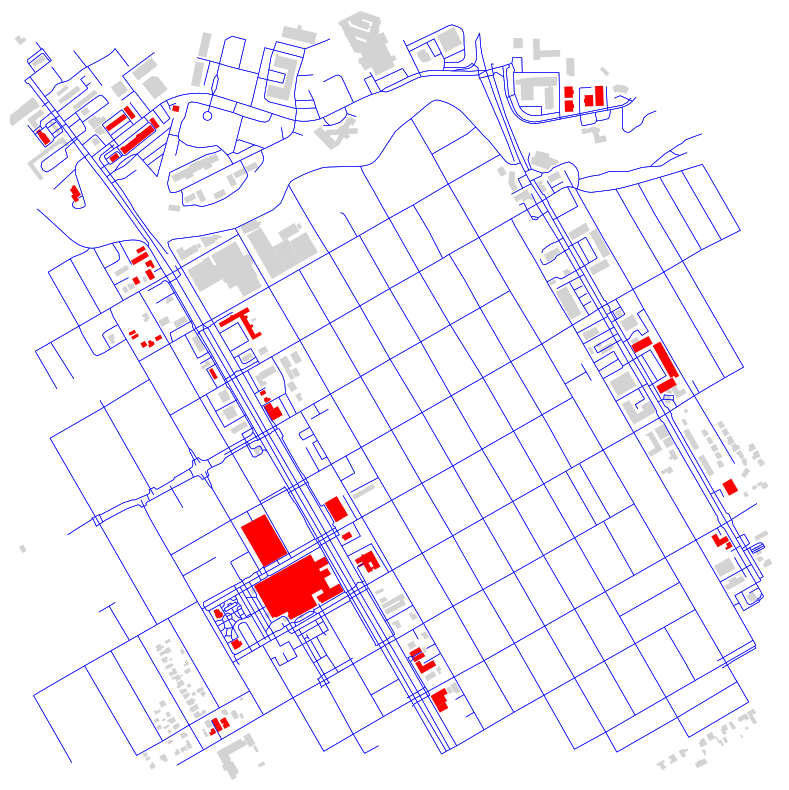

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))
b_small.plot(ax=ax, color="lightgrey", linewidth=0)
b_small[b_small.height_source == "levels"].plot(ax=ax, color="red", linewidth=0)
ox.plot_graph(G_small, ax=ax, node_size=0, edge_linewidth=0.4,
              edge_color="blue", show=False, close=False)
plt.show()